# Run optimiser for different Cherry Tables

## Imports

In [38]:
import pickle
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
import functions as func
from scipy.optimize import minimize, Bounds
from tqdm import tqdm
import pandas as pd
from importlib import reload
from statistics import NormalDist
import matplotlib.pyplot as plt
from hashlib import sha256
import mmh3
reload(func)

<module 'functions' from 'c:\\Users\\psymf9\\PhD Repositories\\cherry-picking-reduction-functions\\plots\\higher_costs\\N_16\\constructing_table\\functions.py'>

## Constants

In [23]:
N = 2 ** 16
p = 1-e**-2 # our table coverage
cost_factors = range(5, 31, 5)  # cost factors to simulate
alpha = 0.95  # maximality factor

## Numerical Optimisation

In [ ]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor, lower_bound):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    bound = Bounds([lower_bound for i in range(t)], [float('inf') for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = func.vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - func.cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: func.m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1})
    
    ## res.x is the result of the optimization
    final_cost, m_values = func.cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Smth Smth Smth

### Adjust m_t in simulation

In [25]:
# adjust the sumulated cost and m_t
def adjust_simulation(m_values, final_cost, N):
    # try and calculate the last m_t
    m = m_values[-1]
    vcost = final_cost

    # Calculate E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    average = N * (1 - E1)

    # check variance
    if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:
        # if it is negative (error), set it to 0
        variance = 0
    else:
        # count the variance otherwise
        variance = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

    # add on the number of hashes done - no reductions as we are just doing mod which is already fast
    vcost =  vcost + m + 1 / 577.44 

    # find the m_j+1
    m = average + NormalDist().inv_cdf((1 - pi / 8) / (1 - pi / 4 + 1)) * variance

    # return the adjusted values
    return m, vcost

## Run

### Run Simulation

In [26]:
# run simulation for different alphas
reload(func)

N = 2 ** 16
t = round(log(1-p)/log(1-N**(-1/3)))
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
starpoint_sets = []
optimisation_results = []
optimisation_kis = []
optimisation_cost = []
optimisation_mt = []

for alpha in alphas:
    # run the optimisation
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, 5, 1)
    optimisation_kis.append(kis)
    # adjust the simulation results and store
    adjusted_m, adjusted_cost = adjust_simulation(m_values, final_cost, N)
    m_values.append(adjusted_m)
    result = [kis, m_0, final_cost, m_values]
    optimisation_results.append(result)
    optimisation_cost.append(final_cost)
    # store the simulated m_t
    optimisation_mt.append(adjusted_m)

# store optimisation_results in a pickle file
with open("simulations/cherry_N_20_different_alpha_0.5_0.95_optimisation_results.pkl", "wb") as f:
    pickle.dump(optimisation_results, f)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1371.765145143076
            Iterations: 19
            Function evaluations: 1553
            Gradient evaluations: 19
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1483.9951039235636
            Iterations: 17
            Function evaluations: 1378
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1592.2261053963514
            Iterations: 20
            Function evaluations: 1639
            Gradient evaluations: 20
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1696.9518299065344
            Iterations: 17
            Function evaluations: 1378
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1798.2895110367172
            Iterations: 17
            

### Use Simulation to Build Tables

In [27]:
# need to regenerate the tables for each alpha and store their costs

samples = 1
generation_results = []
generation_mt = []
generation_costs = []

for alpha in alphas:
    # build the actual table - 100 times 
    # first generate starpoints and store them
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
    this_alpha_startpoints = []
    # generate sample sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (cherry_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    starpoint_sets.append(this_alpha_startpoints)

    # build the vanilla table 100 times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        print(starpoints)
        # make the table with these startpoints
        table, rf_indexes, hashes, reductions, duration = func.build_cherry_table(N, t, starpoints, optimisation_kis[i])
        # append to this alpha's tables
        this_alpha_tables.append((table, rf_indexes))
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

# store in a csv file
# store in a csv file
with open("cherry_N_216_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i], optimisation_mt[i]] + generation_mt[i] + [optimisation_cost[i]] + generation_costs[i]
        f_alpha.writerow(row)

{32768, 1, 40971, 8212, 8213, 49175, 8216, 24615, 32810, 57401, 24651, 41038, 8270, 87, 24668, 24673, 16482, 106, 32879, 8305, 16498, 41077, 32890, 49278, 8320, 16516, 8326, 134, 41103, 149, 49304, 24741, 24743, 174, 41146, 41148, 8389, 32972, 49364, 16599, 32986, 49371, 16603, 16609, 32995, 24808, 233, 8426, 57579, 41197, 250, 49407, 16642, 57603, 33026, 8453, 41218, 24885, 33078, 24886, 49465, 313, 33090, 41284, 57671, 328, 57679, 41303, 24920, 345, 49499, 24924, 24928, 8547, 49520, 24946, 57718, 8586, 16785, 24978, 57747, 57748, 41369, 57763, 57765, 8614, 41385, 33200, 438, 57790, 447, 49598, 33224, 49614, 463, 25039, 33233, 57810, 16858, 57819, 16860, 476, 49629, 49628, 33251, 33257, 57835, 41458, 41460, 49666, 49669, 518, 526, 8732, 33317, 8744, 41520, 8762, 578, 16966, 16971, 49748, 41561, 8798, 612, 49774, 25199, 57974, 33401, 636, 41604, 653, 33424, 25235, 41619, 58008, 17048, 25242, 25247, 33440, 683, 58031, 33459, 33462, 33463, 58038, 41656, 8898, 712, 33482, 17107, 8921, 416

Calculating columns: 100%|██████████| 80/80 [00:55<00:00,  1.45it/s]


{49162, 24593, 49178, 57379, 49187, 40996, 49190, 32805, 16424, 32808, 24627, 41013, 57404, 24636, 49226, 24651, 77, 49235, 85, 49242, 57436, 24670, 8288, 100, 16486, 24682, 32879, 41076, 41077, 32889, 16505, 127, 57475, 57477, 41097, 16522, 8338, 49309, 49311, 16554, 8372, 185, 32953, 49342, 49346, 201, 41162, 203, 8412, 49376, 41185, 57568, 41193, 33009, 8442, 33020, 263, 8461, 8474, 16666, 57627, 49437, 57640, 16685, 16687, 8497, 57663, 330, 41291, 8534, 33111, 33113, 41307, 49504, 24940, 8556, 369, 57714, 57713, 33140, 376, 385, 41348, 57737, 394, 57739, 16778, 33167, 8598, 24990, 49571, 8623, 41413, 33225, 57806, 57815, 8665, 475, 41438, 479, 25060, 8676, 16869, 33262, 57846, 49659, 57855, 57856, 8710, 520, 8713, 41482, 33288, 41494, 534, 57880, 57884, 49693, 8736, 57888, 551, 33320, 8745, 554, 8751, 49720, 41532, 41538, 8775, 8782, 25189, 57961, 17009, 17011, 8825, 57977, 33423, 8858, 33437, 17056, 58017, 41635, 676, 41638, 33447, 25257, 681, 58033, 49844, 33461, 25275, 58046, 41

Calculating columns: 100%|██████████| 80/80 [01:03<00:00,  1.26it/s]


{8192, 49153, 49157, 16395, 49163, 49173, 49175, 40986, 57374, 31, 32806, 32809, 57387, 8237, 24626, 16440, 58, 8250, 41026, 49222, 49229, 82, 49237, 57437, 8285, 41055, 8291, 49267, 115, 8309, 57466, 24699, 32892, 49279, 57471, 41100, 16525, 16530, 49299, 32925, 41119, 24736, 32930, 16547, 24740, 162, 49320, 16554, 24750, 16560, 41136, 41142, 57528, 49345, 8389, 41157, 8392, 203, 8396, 205, 57550, 210, 32982, 218, 32986, 41181, 222, 231, 41196, 8434, 24825, 250, 57594, 41215, 256, 8450, 41219, 24837, 24845, 8463, 33042, 24867, 8486, 24871, 16691, 57653, 33081, 49475, 24900, 16708, 8524, 16718, 336, 8529, 41300, 49493, 8539, 8543, 16739, 8561, 41330, 24947, 8563, 24951, 376, 24953, 57719, 41342, 57728, 8583, 41354, 404, 16793, 8609, 49574, 41384, 16809, 49578, 435, 8630, 33209, 25026, 41411, 16836, 33221, 57800, 41423, 8656, 49626, 33243, 8667, 8666, 57822, 16864, 16865, 16868, 49645, 49648, 49652, 16889, 57853, 16895, 57859, 16901, 25094, 57862, 41489, 57878, 57880, 539, 41501, 16930,

...

Calculating columns: 100%|██████████| 80/80 [02:26<00:00,  1.83s/it]


{32776, 32780, 13, 12, 32784, 17, 19, 32787, 32789, 20, 32792, 25, 31, 32800, 34, 35, 32808, 32812, 44, 46, 32815, 32817, 50, 52, 58, 60, 61, 32828, 64, 65, 32837, 32838, 70, 32841, 75, 77, 80, 81, 82, 32851, 32856, 32858, 91, 32860, 94, 32862, 32864, 99, 101, 104, 107, 109, 110, 113, 115, 32889, 124, 127, 32901, 32903, 143, 146, 32916, 148, 150, 32917, 153, 154, 32925, 158, 32928, 161, 167, 32943, 176, 177, 178, 32944, 32949, 186, 32956, 189, 32959, 32960, 32961, 194, 32963, 32966, 32967, 201, 204, 32976, 211, 32980, 32981, 212, 215, 220, 224, 32993, 227, 32996, 33002, 33003, 237, 33010, 242, 33013, 245, 246, 248, 33014, 33015, 33019, 33023, 257, 33026, 33028, 33034, 33035, 274, 275, 33050, 33051, 283, 285, 33056, 33057, 33059, 33060, 33062, 295, 33064, 297, 33066, 33065, 33069, 303, 306, 33075, 33076, 317, 320, 33090, 325, 33094, 328, 33097, 333, 334, 33106, 33110, 33112, 345, 346, 33115, 33119, 353, 356, 358, 361, 362, 33134, 33139, 373, 374, 376, 379, 381, 33154, 33166, 406, 410, 4

Calculating columns: 100%|██████████| 80/80 [02:52<00:00,  2.16s/it]


{1, 3, 6, 7, 8, 13, 20, 22, 23, 24, 26, 29, 35, 36, 37, 44, 50, 57, 58, 61, 62, 64, 66, 68, 71, 73, 83, 87, 88, 89, 90, 92, 93, 97, 99, 102, 104, 106, 107, 110, 111, 117, 120, 121, 123, 124, 126, 130, 131, 132, 133, 139, 140, 143, 145, 146, 147, 148, 149, 151, 152, 157, 161, 163, 165, 168, 172, 174, 175, 176, 178, 183, 184, 188, 191, 194, 195, 196, 198, 200, 202, 203, 204, 205, 206, 207, 209, 210, 211, 217, 222, 224, 225, 230, 232, 235, 237, 239, 247, 249, 250, 254, 255, 257, 258, 260, 265, 266, 267, 268, 274, 280, 287, 288, 289, 291, 292, 293, 294, 296, 297, 300, 305, 307, 308, 312, 313, 314, 319, 323, 324, 327, 329, 331, 332, 334, 336, 338, 339, 340, 341, 344, 347, 348, 350, 352, 353, 354, 356, 358, 360, 362, 367, 368, 372, 373, 374, 375, 380, 382, 383, 385, 387, 389, 392, 393, 394, 395, 399, 400, 401, 406, 407, 409, 412, 414, 415, 417, 418, 420, 422, 423, 427, 428, 430, 431, 432, 435, 436, 438, 440, 441, 444, 447, 449, 451, 452, 454, 458, 461, 462, 464, 466, 468, 470, 471, 473, 475,

Calculating columns: 100%|██████████| 80/80 [03:38<00:00,  2.73s/it]


### Get vanilla Table values 


In [42]:
def get_vanilla(): # need to regenerate the tables for each alpha and store their costs
    reload(func)

    N = 2 ** 16
    t= round(log(1-p)/log(1-N**(-1/3)))
    alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

    samples = 20
    generation_results = []
    generation_mt = []
    generation_costs = []

    for alpha in alphas:
        # build the actual table - 100 times 
        # first generate starpoints and store them
        mt_max = (2*N)/(t+2)
        mt_target = alpha * mt_max
        vanilla_m_0 = round(mt_target/(1-alpha))    # our starting m_0
        this_alpha_startpoints = []
        # generate sample sets of starpoints
        for i in range(samples):
            starpoints = set()
            while len(starpoints) < (vanilla_m_0):
                starpoints.add(random.randint(0, N-1))

            this_alpha_startpoints.append(starpoints)
        # append to main list
        starpoint_sets.append(this_alpha_startpoints)

        # build the vanilla table 100 times and store it for later
        this_alpha_tables = []
        this_alpha_mt = []
        this_alpha_costs = []
        for i in range(samples):
            # get starpoints
            starpoints = this_alpha_startpoints[i]
            # make the table with these startpoints
            table, hashes, reductions = func.build_vanilla_table_with_costs(N, t, starpoints)
            # append to this alpha's tables
            this_alpha_tables.append(table)
            this_alpha_mt.append(len(table))
            this_alpha_costs.append(hashes)
        
        # append to main list
        generation_results.append(this_alpha_tables)
        generation_mt.append(this_alpha_mt)
        generation_costs.append(this_alpha_costs)

    # store in a csv file
    # store in a csv file
    with open("vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
        f_alpha = csv.writer(f) # create a csv writer

        # create a list of headers for the different trials
        trial_headers = []
        cost_headers = []
        for i in range(samples):
            trial_headers.append(f"trial_{i+1}")
            cost_headers.append(f"cost_{i+1}")
        
        f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

        # add in data for each alpha
        for i in range(len(alphas)):
            row = [alphas[i], optimisation_mt[i]] + generation_mt[i] + [optimisation_cost[i]] + generation_costs[i]
            f_alpha.writerow(row)


get_vanilla()

 62%|██████▏   | 18911/30370 [00:02<00:01, 8279.59it/s]


KeyboardInterrupt: 

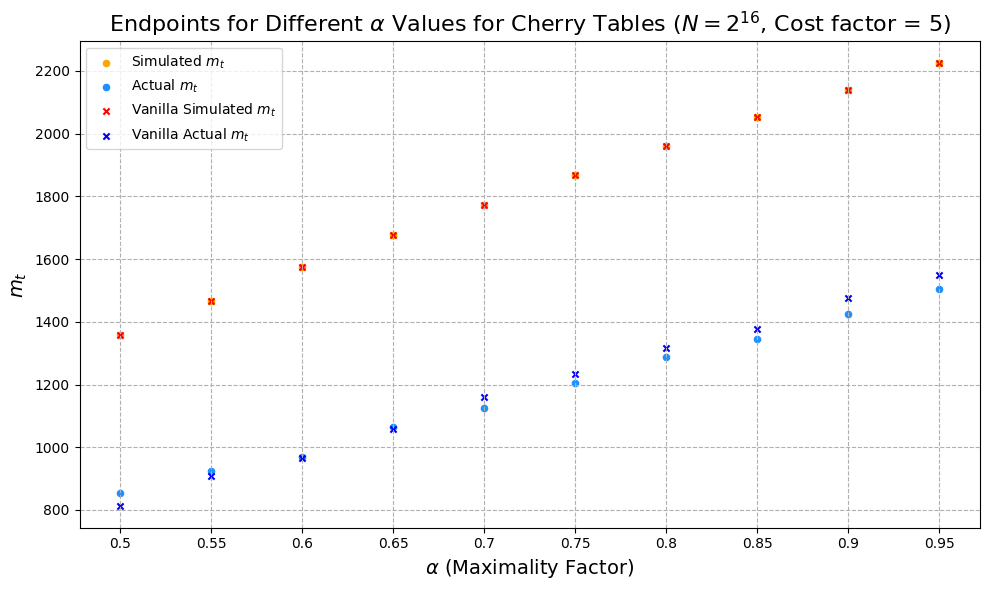

In [40]:
# plot scatter plot of optimisation mt vs generated mt
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

# # plot simulated cost as scatter
plt.scatter(x_indicies, optimisation_mt, color='orange', label='Simulated $m_t$ ', s=20)
plt.scatter(x_indicies, [mt[0] for mt in generation_mt], color='dodgerblue', label='Actual $m_t$', s=20)
# plot simulated and actual for vanilla tables as well
data = pd.read_csv("vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv")
x_indicies = range(len(alphas))
plt.scatter(x_indicies, data['optimiser_mt'], color='red', label='Vanilla Simulated $m_t$', s=20, marker='x')
plt.scatter(x_indicies, [mt[0] for mt in data.iloc[:,2:22].values], color='blue', label='Vanilla Actual $m_t$', s=20, marker='x')

plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for Cherry Tables ($N=2^{16}$, Cost factor = 5)', fontsize=16)
plt.legend()
plt.tight_layout()  
plt.show()

In [ ]:
# maybe plot m values for alpha = 0.5 for simulated vs actual?
# need to get the m values for alpha = 0.5 when building the table 
def H(x):
    return sha256(x.to_bytes(8, 'little')).digest()  # return bytes directly

def r(y, i, ell=0):
    return mmh3.hash(y, i + ell*t, signed=False) % N

def get_m_values(N, t, startpoints, Kis):
    m_values = []
    # store table in dictionary
    # initialise the table with sp:sp pairs
    table = {sp: sp for sp in startpoints}  # store all the points then remove duplicate entries - can't do duplicate keys in dictionary anyway so we can just store all ep:sp
    m_values.append(len(table))
    # Instead of making the table chain by chain, we have to make it column by column to test what reduction function to choose
    # store reduction function indexes
    rf_indexes = []

    # for each column
    for i in tqdm(range(t), desc=f"Calculating columns: "):

        # variable to store best cherry-pick
        best_trial = -1

        # hash all current points then store with startpoints - this stores all our current points
        hashed_points = {H(mi): sp for mi, sp in table.items()}

        # we are going to continuously replace table with the best rf trial, so we empty it for now
            # we haven't lost the current points as we have them hashed in the hashed_points dictionary
        table = {}

        # get # cherry-picks for this column
        k_i = round(Kis[i])

        # trial all the reduction functions for this column
        # for rf_trial in tqdm(range(k_i), desc=f"Choosing best RF: "):
        for rf_trial in range(k_i):

            # create a trial column to store results of current trial
            trial_column = {}

            # go through each key in hashed_points and store its reduction with sp
            for x in hashed_points:
                # reduce the hash and store in column
                trial_column[r(x, rf_trial)] = hashed_points[x]

            # if trial_column is bigger than current table stored, we replace it
            if len(trial_column) > len(table):
                # replace it 
                table = trial_column
                # replace best cherry-pick
                best_trial = rf_trial

        # now store the best rf cherry pick
        rf_indexes.append(best_trial)
        # store the m value
        m_values.append(len(table))


    # finished, so return table and rf indexes
    return m_values


def get_vanilla_m_values(t, alpha, startpoints):
    m_values = []

    # list of sets to store unique values in each column
    m_i_sets = [set() for _ in range(t)]
    print(len(m_i_sets))

    # keep track of what column we're in
    column = 0

    # for each startpoint
    for sp in tqdm(startpoints):
        current_point = sp  # keep track of current point in chain -  we want to store startpoint later
        m_i_sets[column].add(current_point)  # add startpoint to first column set

        # create the chain
        for i in range(t):
            # hash then reduce the value
            current_point = r(H(current_point), i)
            m_i_sets[i].add(current_point)  # add current point to the corresponding column set
            # move to next column
            column += 1

        # finished the chain - reset column counter
        column = 0

    # now calculate mi values from the sets
    for i in range(t):
        m_values.append(len(m_i_sets[i]))


    return m_values


Calculating columns: 100%|██████████| 80/80 [01:00<00:00,  1.33it/s]


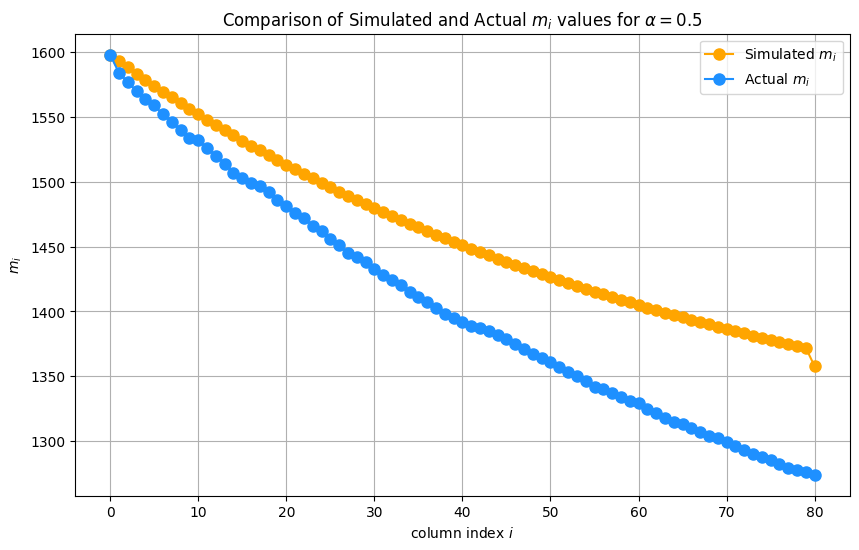

In [36]:
# get simulated m values for alpha = 0.5
# create a set of starpoints
alpha = 0.5
mt_max = (2*N)/(t+2)
mt_target = alpha * mt_max
cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
cherry_startpoints = set()
while len(cherry_startpoints) < (cherry_m_0):
    cherry_startpoints.add(random.randint(0, N-1))

actual_m_values = get_m_values(N, t, cherry_startpoints, optimisation_kis[0])
# get actual m values for alpha = 0.5
simulated_m_values = optimisation_results[0][3]

# plot both sets of m values
plt.figure(figsize=(10,6))
plt.plot(range(t+1), simulated_m_values, marker='o', color='orange', label='Simulated $m_i$ ', markersize=8)
plt.plot(range(t+1), actual_m_values, marker='o', color='dodgerblue', label='Actual $m_i$', markersize=8)
plt.legend()
plt.xlabel('column index $i$')
plt.ylabel('$m_i$')
plt.title('Comparison of Simulated and Actual $m_i$ values for $\\alpha=0.5$')
plt.grid(True)
plt.show()